In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math
from itertools import combinations

data_dir = "../data"
prompts_dir = "../prompts"
predictions_dir = "../predictions"
results_dir = "../results"

In [2]:
results = {}

for model in os.listdir(results_dir):
    df = pd.read_csv(os.path.join(results_dir, model))
    results[model.split('.csv')[0]] = df

In [3]:
models = ['gemini-2.0-flash', 'claude-opus-4', 'llama-3.1-8b', 'claude-3.5-haiku', 'llama-3.1-405b']
# cases = ['both', 'neither', 'pro', 'con']
stances = ['con', 'other', 'pro']
colors = {'con': 'royalblue', 'pro': 'orange', 'other': 'lightgray'}

remove_issues = [
    'corporal-punishment', 'dare-drug-abuse-resistance-education', 'tablets-vs-textbooks',
    # 'immigration', 'birth-control', 'golf',
]

In [ ]:
for model in models:
    df = results[model]
    cases_of_interest = ['neither', 'all']
    cases = df['case'].unique()
    df = df[df['case'].isin(cases_of_interest)]
    issues = df['issue'].unique()
    issues = issues[~np.isin(issues, remove_issues)]
    n_issues = len(issues)

    ncols = 4  # Adjust as needed for readability
    nrows = math.ceil(n_issues / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*2.5), squeeze=False)

    for idx, issue in enumerate(issues):
        row, col = divmod(idx, ncols)
        ax = axes[row, col]
        filtered = df[df['issue'] == issue]
        cases = filtered['case'].unique()
        data = []
        for case in cases:
            sub = filtered[filtered['case'] == case]
            counts = sub.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
            shares = counts / counts.sum() if counts.sum() > 0 else counts
            data.append(shares.values)
        if len(data) == 0:
            continue
        data_df = pd.DataFrame(data, columns=stances, index=cases)
        left = pd.Series([0]*len(data_df), index=data_df.index)
        for stance in stances:
            ax.barh(data_df.index, data_df[stance], left=left, color=colors[stance], label=stance)
            left += data_df[stance]
        ax.set_title(issue)
        ax.set_xlabel('Share')
        ax.set_xlim(0, 1)
        if col == 0:
            ax.set_ylabel('Case')
        else:
            ax.set_yticklabels([])
        
        ax.legend().set_visible(False)

    # Hide any unused subplots
    for idx in range(n_issues, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row, col].axis('off')

    handles = [plt.Rectangle((0,0),1,1, color=colors[stance]) for stance in stances]
    labels = [stance.capitalize() for stance in stances]
    fig.legend(handles, labels, title='Stance', loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=3, fontsize=20, title_fontsize=24)

    fig.suptitle(f"Model: {model}, Cases: {' and '.join(cases_of_interest)}", fontsize=32)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space at the top for the suptitle
    plt.savefig(f"../figures/{model}_neither_both_run2.png", dpi=300)

In [ ]:
for model in models:
    df = results[model]
    cases_of_interest = ['pro', 'con']
    cases = df['case'].unique()
    df = df[df['case'].isin(cases_of_interest)]
    issues = df['issue'].unique()
    issues = issues[~np.isin(issues, remove_issues)]
    n_issues = len(issues)

    ncols = 4  # Adjust as needed for readability
    nrows = math.ceil(n_issues / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*2.5), squeeze=False)

    for idx, issue in enumerate(issues):
        row, col = divmod(idx, ncols)
        ax = axes[row, col]
        filtered = df[df['issue'] == issue]
        cases = filtered['case'].unique()
        data = []
        for case in cases:
            sub = filtered[filtered['case'] == case]
            counts = sub.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
            shares = counts / counts.sum() if counts.sum() > 0 else counts
            data.append(shares.values)
        if len(data) == 0:
            continue
        data_df = pd.DataFrame(data, columns=stances, index=cases)
        left = pd.Series([0]*len(data_df), index=data_df.index)
        for stance in stances:
            ax.barh(data_df.index, data_df[stance], left=left, color=colors[stance], label=stance)
            left += data_df[stance]
        ax.set_title(issue)
        ax.set_xlabel('Share')
        ax.set_xlim(0, 1)
        if col == 0:
            ax.set_ylabel('Case')
        else:
            ax.set_yticklabels([])
        
        ax.legend().set_visible(False)

    # Hide any unused subplots
    for idx in range(n_issues, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row, col].axis('off')

    handles = [plt.Rectangle((0,0),1,1, color=colors[stance]) for stance in stances]
    labels = [stance.capitalize() for stance in stances]
    fig.legend(handles, labels, title='Stance', loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=3, fontsize=20, title_fontsize=24)

    fig.suptitle(f"Model: {model}, Cases: {' and '.join(cases_of_interest)}", fontsize=32)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space at the top for the suptitle
    plt.savefig(f"../figures/{model}_pro_con_run2.png", dpi=300)

In [ ]:
for model in models:
    df = results[model]
    cases_of_interest = ['75pro', '75con']
    cases = df['case'].unique()
    df = df[df['case'].isin(cases_of_interest)]
    issues = df['issue'].unique()
    issues = issues[~np.isin(issues, remove_issues)]
    n_issues = len(issues)

    ncols = 4  # Adjust as needed for readability
    nrows = math.ceil(n_issues / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*2.5), squeeze=False)

    for idx, issue in enumerate(issues):
        row, col = divmod(idx, ncols)
        ax = axes[row, col]
        filtered = df[df['issue'] == issue]
        cases = filtered['case'].unique()
        data = []
        for case in cases:
            sub = filtered[filtered['case'] == case]
            counts = sub.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
            shares = counts / counts.sum() if counts.sum() > 0 else counts
            data.append(shares.values)
        if len(data) == 0:
            continue
        data_df = pd.DataFrame(data, columns=stances, index=cases)
        left = pd.Series([0]*len(data_df), index=data_df.index)
        for stance in stances:
            ax.barh(data_df.index, data_df[stance], left=left, color=colors[stance], label=stance)
            left += data_df[stance]
        ax.set_title(issue)
        ax.set_xlabel('Share')
        ax.set_xlim(0, 1)
        if col == 0:
            ax.set_ylabel('Case')
        else:
            ax.set_yticklabels([])
        
        ax.legend().set_visible(False)

    # Hide any unused subplots
    for idx in range(n_issues, nrows * ncols):
        row, col = divmod(idx, ncols)
        axes[row, col].axis('off')

    handles = [plt.Rectangle((0,0),1,1, color=colors[stance]) for stance in stances]
    labels = [stance.capitalize() for stance in stances]
    fig.legend(handles, labels, title='Stance', loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=3, fontsize=20, title_fontsize=24)

    fig.suptitle(f"Model: {model}, Cases: {' and '.join(cases_of_interest)}", fontsize=32)
    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space at the top for the suptitle
    plt.savefig(f"../figures/{model}_overwhelming_pro_overwhelming_con_run2.png", dpi=300)

In [4]:
models = list(results.keys())
stances = ['con', 'other', 'pro']
models = ['claude-3.5-haiku', 'claude-opus-4', 'gemini-2.0-flash', 'llama-3.1-405b', 'llama-3.1-8b']

# Step 1: Aggregate and normalize to get shares
all_data = []
for model in models:
    df = results[model]
    for (issue, case), group in df.groupby(['issue', 'case']):
        counts = group.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
        total = counts.sum()
        if total > 0:
            shares = counts / total
        else:
            shares = counts
        for stance in stances:
            all_data.append({
                'model': model,
                'issue': issue,
                'case': case,
                'issue_stance': stance,
                'share': shares[stance]
            })

df_shares = pd.DataFrame(all_data)

# Step 2: Pivot so each model's share is a column
pivot = df_shares.pivot_table(
    index=['issue', 'case', 'issue_stance'],
    columns='model',
    values='share'
).reset_index()

# Step 3: Compute max difference between any two models for each row
def max_model_diff(row):
    shares = [row[model] for model in models if pd.notnull(row[model])]
    if len(shares) < 2:
        return np.nan
    return np.max(shares) - np.min(shares)

def diff_models_max(row):
    shares = [row[model] for model in models if pd.notnull(row[model])]
    if len(shares) < 2:
        return np.nan
    return models[np.argmax(shares)]

def diff_models_min(row):
    shares = [row[model] for model in models if pd.notnull(row[model])]
    if len(shares) < 2:
        return np.nan
    return models[np.argmin(shares)]

def average_model_diff(row):
    diffs = []
    for (model_1, model_2) in combinations(models, 2):
        diffs.append(abs(row[model_1] - row[model_2]))
    if len(diffs) < 2:
        return np.nan
    return np.mean(diffs)

def variance_model_diff(row):
    diffs = []
    for (model_1, model_2) in combinations(models, 2):
        diffs.append(abs(row[model_1] - row[model_2]))
    if len(diffs) < 2:
        return np.nan
    return np.var(diffs)

pivot['max_diff'] = pivot.apply(max_model_diff, axis=1)
pivot['diff_models_max'] = pivot.apply(diff_models_max, axis=1)
pivot['diff_models_min'] = pivot.apply(diff_models_min, axis=1)
pivot['average_model_diff'] = pivot.apply(average_model_diff, axis=1)
pivot['variance_model_diff'] = pivot.apply(variance_model_diff, axis=1)

# Step 4: Sort by largest difference
largest_diffs = pivot.sort_values('max_diff', ascending=False)

In [22]:
opus_undecided = pivot[(pivot['case'] == 'neither')][['issue', 'issue_stance', 'claude-opus-4']]
opus_undecided_pivot = opus_undecided.pivot(index='issue', columns='issue_stance', values='claude-opus-4').reset_index()
cols = ['issue', 'con', 'other', 'pro']
opus_undecided_pivot = opus_undecided_pivot.reindex(columns=cols)
issues_where_opus_is_highly_undecided = opus_undecided_pivot[opus_undecided_pivot['other'] == opus_undecided_pivot[['con', 'other', 'pro']].max(axis=1)]['issue'].to_list()

In [56]:
base = pivot[
    # only consider neither cases
    (pivot['case'] == 'neither')
    # ignore cases where it's a highly undecided issue for opus
    & ~(pivot['issue'].isin(issues_where_opus_is_highly_undecided))
]
top_k = 12

highest_average_model_diff_issues = base.sort_values(by='average_model_diff', ascending=False)[:top_k][['issue', 'average_model_diff']].groupby('issue').first()
highest_variance_model_diff_issues = base.sort_values(by='variance_model_diff', ascending=False)[:top_k][['issue', 'variance_model_diff']].groupby('issue').first()
highest_max_model_diff_issues = base.sort_values(by='max_diff', ascending=False)[:top_k][['issue', 'max_diff']].groupby('issue').first()

print("BASELINE CASE (NO EVIDENCE); EXCLUDING THE FOLLOWING HIGHLY UNDECIDED TOPICS FOR OPUS:")
for issue in sorted(issues_where_opus_is_highly_undecided, key=lambda x: x[0]):
    print(f"- {issue}")
print()
print('=' * 100)
print("Issues with the highest average model disagreement (by average pairwise difference):")
print('=' * 100)
for issue, row in highest_average_model_diff_issues.iterrows():
    print(f"- {issue}: {row['average_model_diff']:.2f}")
print()
print('=' * 100)
print("Issues with the highest variance in model disagreement (by variance of pairwise differences):")
print('=' * 100)
for issue, row in highest_variance_model_diff_issues.iterrows():
    print(f"- {issue}: {row['variance_model_diff']:.2f}")
print()
print('=' * 100)
print("Issues with the highest maximum model disagreement (by max difference of pairwise differences):")
print('=' * 100)
for issue, row in highest_max_model_diff_issues.iterrows():
    print(f"- {issue}: {row['max_diff']:.2f}")
print()

all_issues = list(set(highest_average_model_diff_issues.index.tolist() + highest_variance_model_diff_issues.index.tolist() + highest_max_model_diff_issues.index.tolist()))

print('=' * 100)
print("All issues:")
print('=' * 100)
for issue in all_issues:
    print(f"- {issue}")
print('=' * 100)

BASELINE CASE (NO EVIDENCE); EXCLUDING THE FOLLOWING HIGHLY UNDECIDED TOPICS FOR OPUS:
- abortion
- american-socialism
- constitutional-carry-of-guns
- dakota-access-pipeline
- defund-the-police
- gun-control
- reparations-for-slavery
- sanctuary-cities
- universal-health-care

Issues with the highest average model disagreement (by average pairwise difference):
- binge-watching: 0.40
- drones: 0.37
- fighting-in-hockey: 0.36
- gig-economy: 0.38
- historical-statue-removal: 0.37
- mandatory-national-service: 0.32
- school-uniforms: 0.40

Issues with the highest variance in model disagreement (by variance of pairwise differences):
- binge-watching: 0.10
- cancel-culture: 0.06
- fighting-in-hockey: 0.07
- gig-economy: 0.06
- historical-statue-removal: 0.07
- minimum-wage: 0.07
- school-uniforms: 0.11
- teacher-tenure: 0.08

Issues with the highest maximum model disagreement (by max difference of pairwise differences):
- binge-watching: 0.83
- drones: 0.73
- fighting-in-hockey: 0.73
- gig-

In [73]:
# --- Model Open-Mindedness Metric (Pro Share) ---

openmindedness_results = {}
non_baseline_cases = ['pro', '75pro', 'all', '75con', 'con']
baseline_case = 'neither'

for model in models:
    df = results[model]
    # Compute baseline pro/con share for each issue
    baseline = df[df['case'] == baseline_case].groupby('issue').apply(
        lambda g: g.set_index('issue_stance')['count'] / g['count'].sum()
    ).unstack().fillna(0)
    # Compute pro share for each non-baseline case
    shifts = []
    for case in non_baseline_cases:
        case_df = df[df['case'] == case].groupby('issue').apply(
            lambda g: g.set_index('issue_stance')['count'] / g['count'].sum()
        ).unstack().fillna(0)
        for issue in baseline.index:
            if issue in case_df.index:
                baseline_pro = baseline.loc[issue].get('pro', 0)
                case_pro = case_df.loc[issue].get('pro', 0)
                shift = case_pro - baseline_pro
                shifts.append({'model': model, 'issue': issue, 'case': case, 'shift': shift, 'baseline_pro': baseline_pro, 'baseline_con': baseline.loc[issue].get('con', 0)})
    openmindedness_results[model] = pd.DataFrame(shifts)

# Aggregate open-mindedness per model and per issue
summary = []
for model, df in openmindedness_results.items():
    # Average shift per issue
    avg_shift_per_issue = df.groupby('issue')['shift'].mean()
    # Overall average
    overall_avg = avg_shift_per_issue.mean()
    # Bucketize issues
    buckets = {}
    for issue in avg_shift_per_issue.index:
        baseline_pro = df[df['issue'] == issue]['baseline_pro'].iloc[0]
        baseline_con = df[df['issue'] == issue]['baseline_con'].iloc[0]
        if baseline_pro > 0.8:
            bucket = 'strongest in favor'
        elif baseline_con > 0.8:
            bucket = 'strongest against'
        else:
            bucket = 'middle'
        buckets[issue] = bucket
    # Outliers
    outlier_high = avg_shift_per_issue.idxmax()
    outlier_low = avg_shift_per_issue.idxmin()
    summary.append({
        'model': model,
        'overall_avg_shift': overall_avg,
        'outlier_high_issue': outlier_high,
        'outlier_high_value': avg_shift_per_issue[outlier_high],
        'outlier_high_bucket': buckets[outlier_high],
        'outlier_low_issue': outlier_low,
        'outlier_low_value': avg_shift_per_issue[outlier_low],
        'outlier_low_bucket': buckets[outlier_low],
        'bucket_counts': pd.Series(buckets).value_counts().to_dict()
    })
    # print(f"\nModel: {model}")
    # print(f"  Overall average open-mindedness (mean pro share shift): {overall_avg:.3f}")
    # print(f"  Outlier (highest shift): {outlier_high} ({avg_shift_per_issue[outlier_high]:.3f}, bucket: {buckets[outlier_high]})")
    # print(f"  Outlier (lowest shift): {outlier_low} ({avg_shift_per_issue[outlier_low]:.3f}, bucket: {buckets[outlier_low]})")
    # print(f"  Issue buckets: {pd.Series(buckets).value_counts().to_dict()}")
    # print(f"  Top 5 most open-minded issues:")
    # print(avg_shift_per_issue.sort_values(ascending=False).head(5))
    # print(f"  Top 5 least open-minded issues:")
    # print(avg_shift_per_issue.sort_values().head(5))

# Optionally, collect summary as DataFrame for further analysis
openmindedness_summary = pd.DataFrame(summary)

/var/folders/sn/nd2vlwp52w94trc8v9nb46bc0000gp/T/ipykernel_95238/572295229.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  baseline = df[df['case'] == baseline_case].groupby('issue').apply(
/var/folders/sn/nd2vlwp52w94trc8v9nb46bc0000gp/T/ipykernel_95238/572295229.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  case_df = df[df['case'] == case].groupby('issue').apply(
/var/folders/sn/nd2vlwp52w94trc8v9nb46bc

In [77]:
openmindedness_results['llama-3.1-8b']

,model,issue,case,shift,baseline_pro,baseline_con
0,llama-3.1-8b,abortion,pro,0.000000,1.000000,0.000000
1,llama-3.1-8b,alternative-energy,pro,0.000000,0.666667,0.333333
2,llama-3.1-8b,american-civil-liberties-union-aclu,pro,0.000000,0.666667,0.333333
3,llama-3.1-8b,american-socialism,pro,-0.166667,0.833333,0.166667
4,llama-3.1-8b,animal-dissection,pro,0.250000,0.666667,0.333333
...,...,...,...,...,...,...
411,llama-3.1-8b,video-games,con,-0.577778,0.666667,0.333333
412,llama-3.1-8b,voting-age,con,-0.333333,0.500000,0.500000
413,llama-3.1-8b,voting-machines,con,-0.072222,0.333333,0.666667
414,llama-3.1-8b,wtc-muslim-center,con,-0.600000,0.833333,0.166667


In [74]:
summary

[{'model': 'claude-3.5-haiku',
  'overall_avg_shift': np.float64(-0.07101495726495727),
  'outlier_high_issue': 'private-prisons',
  'outlier_high_value': np.float64(0.43888888888888894),
  'outlier_high_bucket': 'strongest against',
  'outlier_low_issue': 'dress-codes',
  'outlier_low_value': np.float64(-0.508888888888889),
  'outlier_low_bucket': 'strongest in favor',
  'bucket_counts': {'middle': 54,
   'strongest in favor': 34,
   'strongest against': 16}},
 {'model': 'claude-opus-4',
  'overall_avg_shift': np.float64(0.010544871794871792),
  'outlier_high_issue': 'cell-phones',
  'outlier_high_value': np.float64(0.4177777777777777),
  'outlier_high_bucket': 'strongest against',
  'outlier_low_issue': 'zoos',
  'outlier_low_value': np.float64(-0.5266666666666666),
  'outlier_low_bucket': 'strongest in favor',
  'bucket_counts': {'middle': 66,
   'strongest in favor': 21,
   'strongest against': 17}},
 {'model': 'gemini-2.0-flash',
  'overall_avg_shift': np.float64(-0.08909837937612

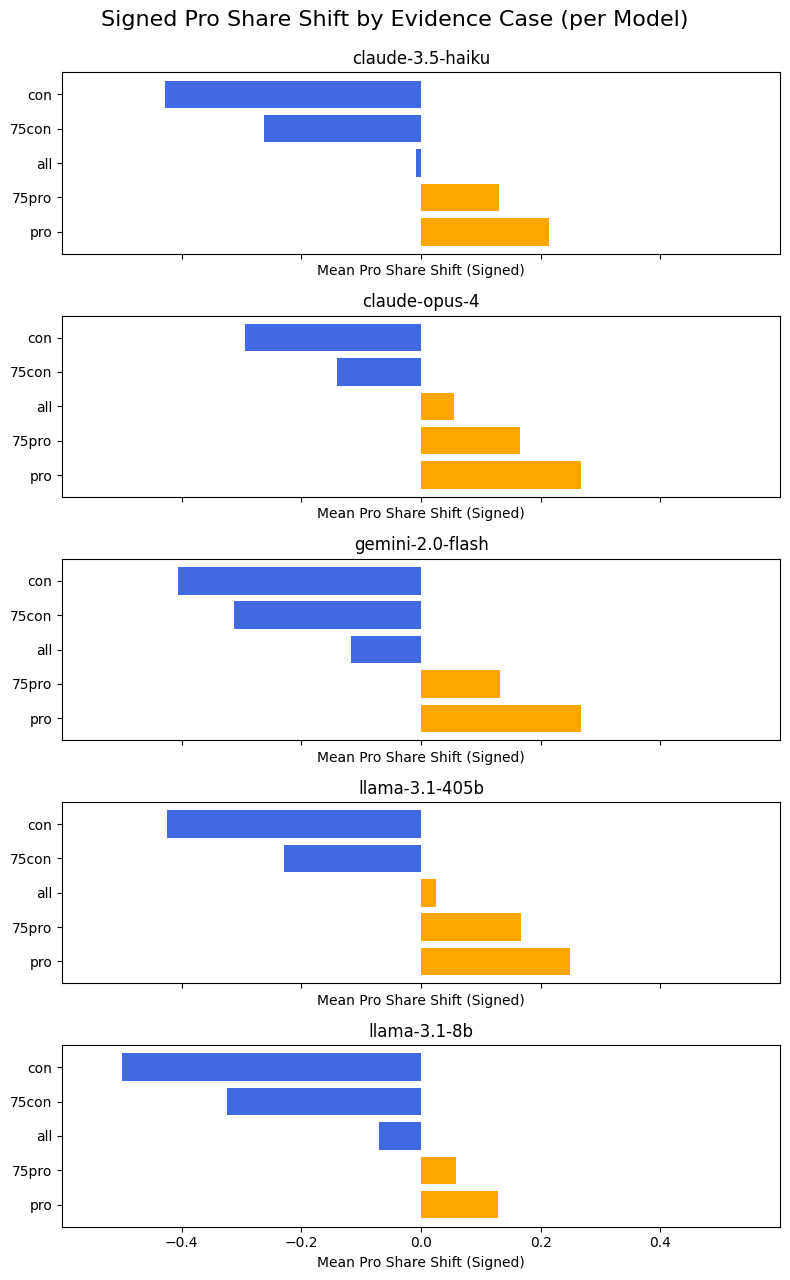

In [72]:
case_order = ['con', '75con', 'all', '75pro', 'pro']
baseline_case = 'neither'

fig, axes = plt.subplots(len(models), 1, figsize=(8, 2.5 * len(models)), sharex=True)
if len(models) == 1:
    axes = [axes]

for i, model in enumerate(models):
    df = results[model]
    # Use pivot_table for baseline
    baseline = df[df['case'] == baseline_case].pivot_table(
        index='issue',
        columns='issue_stance',
        values='count',
        aggfunc='sum',
        fill_value=0
    )
    baseline = baseline.div(baseline.sum(axis=1), axis=0).fillna(0)
    avg_shifts = []
    for case in case_order:
        # Use pivot_table for case_df
        case_df = df[df['case'] == case].pivot_table(
            index='issue',
            columns='issue_stance',
            values='count',
            aggfunc='sum',
            fill_value=0
        )
        case_df = case_df.div(case_df.sum(axis=1), axis=0).fillna(0)
        shifts = []
        for issue in baseline.index:
            if issue in case_df.index:
                baseline_pro = baseline.loc[issue].get('pro', 0)
                case_pro = case_df.loc[issue].get('pro', 0)
                shift = case_pro - baseline_pro  # signed difference
                shifts.append(shift)
        avg_shifts.append(np.mean(shifts) if shifts else 0)
    bars = axes[i].barh(case_order, avg_shifts, color=['royalblue' if v < 0 else 'orange' for v in avg_shifts])
    axes[i].set_title(f"{model}")
    axes[i].invert_yaxis()  # So 'con' is at the top
    # Set symmetric x-limits for better visual comparison
    max_abs = max(abs(min(avg_shifts)), abs(max(avg_shifts)), 0.1)
    axes[i].set_xlim(-max_abs * 1.2, max_abs * 1.2)
    axes[i].set_xlabel('Mean Pro Share Shift (Signed)')
    axes[i].set_yticks(np.arange(len(case_order)))
    axes[i].set_yticklabels(case_order)
plt.tight_layout()
plt.suptitle('Signed Pro Share Shift by Evidence Case (per Model)', y=1.02, fontsize=16)
plt.show()

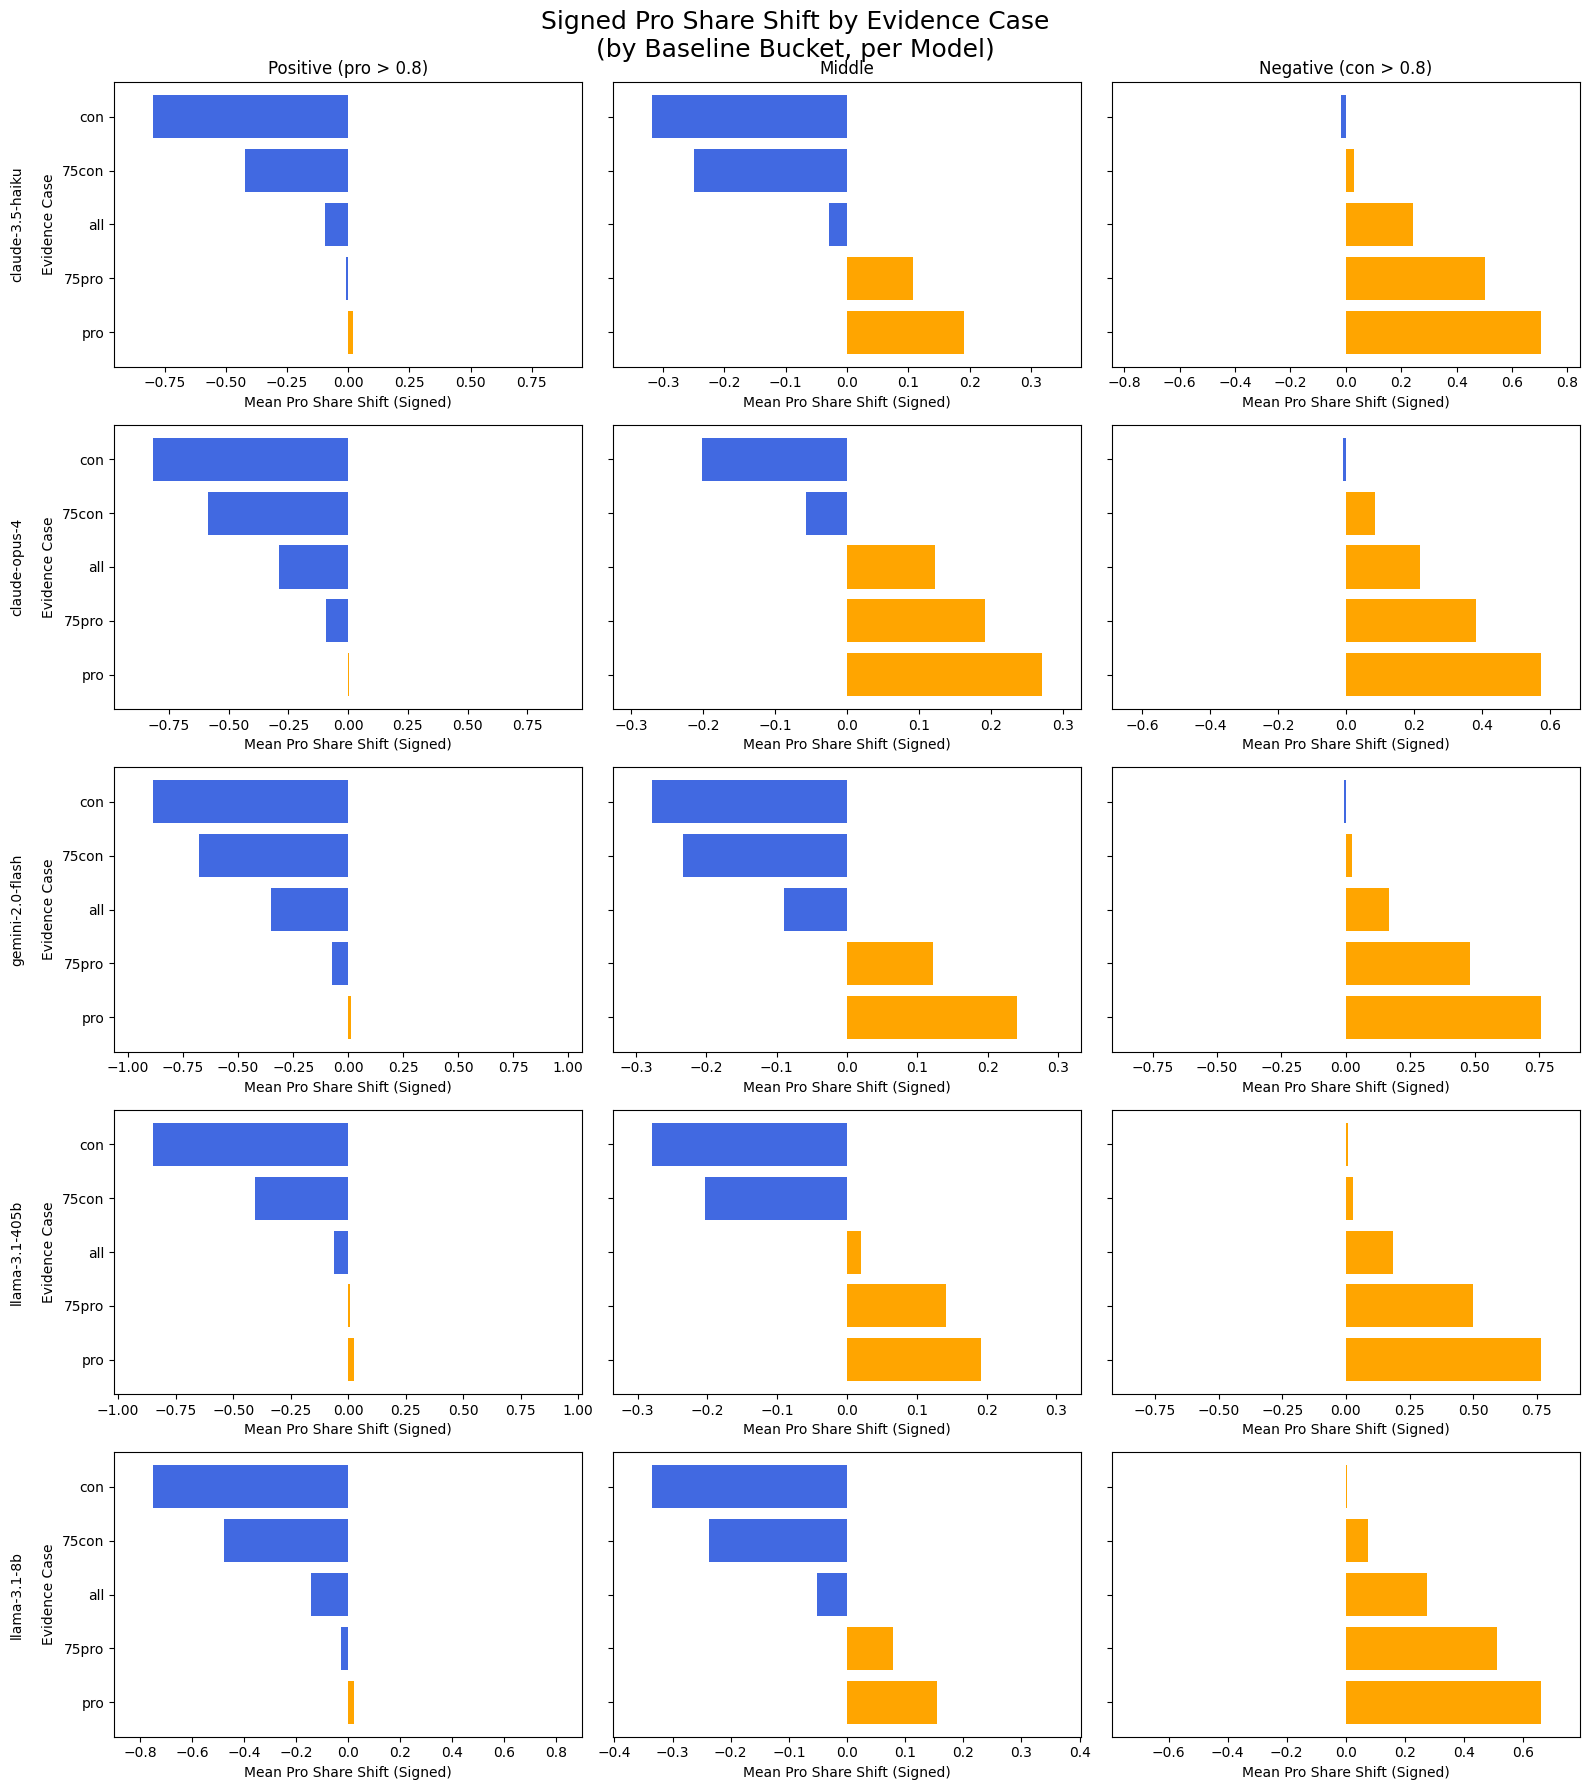

In [79]:

case_order = ['con', '75con', 'all', '75pro', 'pro']
baseline_case = 'neither'
buckets = ['Positive (pro > 0.8)', 'Middle', 'Negative (con > 0.8)']

n_models = len(models)
fig, axes = plt.subplots(n_models, 3, figsize=(16, 3.5 * n_models), sharey=True)

for i, model in enumerate(models):
    df = results[model]
    # Compute baseline shares
    baseline = df[df['case'] == baseline_case].pivot_table(
        index='issue',
        columns='issue_stance',
        values='count',
        aggfunc='sum',
        fill_value=0
    )
    baseline = baseline.div(baseline.sum(axis=1), axis=0).fillna(0)
    # Bucket issues
    issue_buckets = {}
    for issue in baseline.index:
        pro_share = baseline.loc[issue].get('pro', 0)
        con_share = baseline.loc[issue].get('con', 0)
        if pro_share > 0.8:
            issue_buckets[issue] = 'Positive (pro > 0.8)'
        elif con_share > 0.8:
            issue_buckets[issue] = 'Negative (con > 0.8)'
        else:
            issue_buckets[issue] = 'Middle'
    for j, bucket in enumerate(buckets):
        bucket_issues = [issue for issue, b in issue_buckets.items() if b == bucket]
        avg_shifts = []
        for case in case_order:
            case_df = df[df['case'] == case].pivot_table(
                index='issue',
                columns='issue_stance',
                values='count',
                aggfunc='sum',
                fill_value=0
            )
            case_df = case_df.div(case_df.sum(axis=1), axis=0).fillna(0)
            shifts = []
            for issue in bucket_issues:
                if issue in case_df.index and issue in baseline.index:
                    baseline_pro = baseline.loc[issue].get('pro', 0)
                    case_pro = case_df.loc[issue].get('pro', 0)
                    shift = case_pro - baseline_pro  # signed difference
                    shifts.append(shift)
            avg_shifts.append(np.mean(shifts) if shifts else 0)
        ax = axes[i, j] if n_models > 1 else axes[j]
        ax.barh(case_order, avg_shifts, color=['royalblue' if v < 0 else 'orange' for v in avg_shifts])
        ax.invert_yaxis()
        max_abs = max(abs(min(avg_shifts)), abs(max(avg_shifts)), 0.1)
        ax.set_xlim(-max_abs * 1.2, max_abs * 1.2)
        if i == 0:
            ax.set_title(bucket)
        if j == 0:
            ax.set_ylabel(f"{model}\n\nEvidence Case")
        else:
            ax.set_ylabel("")
        ax.set_xlabel('Mean Pro Share Shift (Signed)')
        ax.set_yticks(np.arange(len(case_order)))
        ax.set_yticklabels(case_order)
plt.tight_layout()
plt.suptitle('Signed Pro Share Shift by Evidence Case\n(by Baseline Bucket, per Model)', y=1.02, fontsize=18)
plt.show()

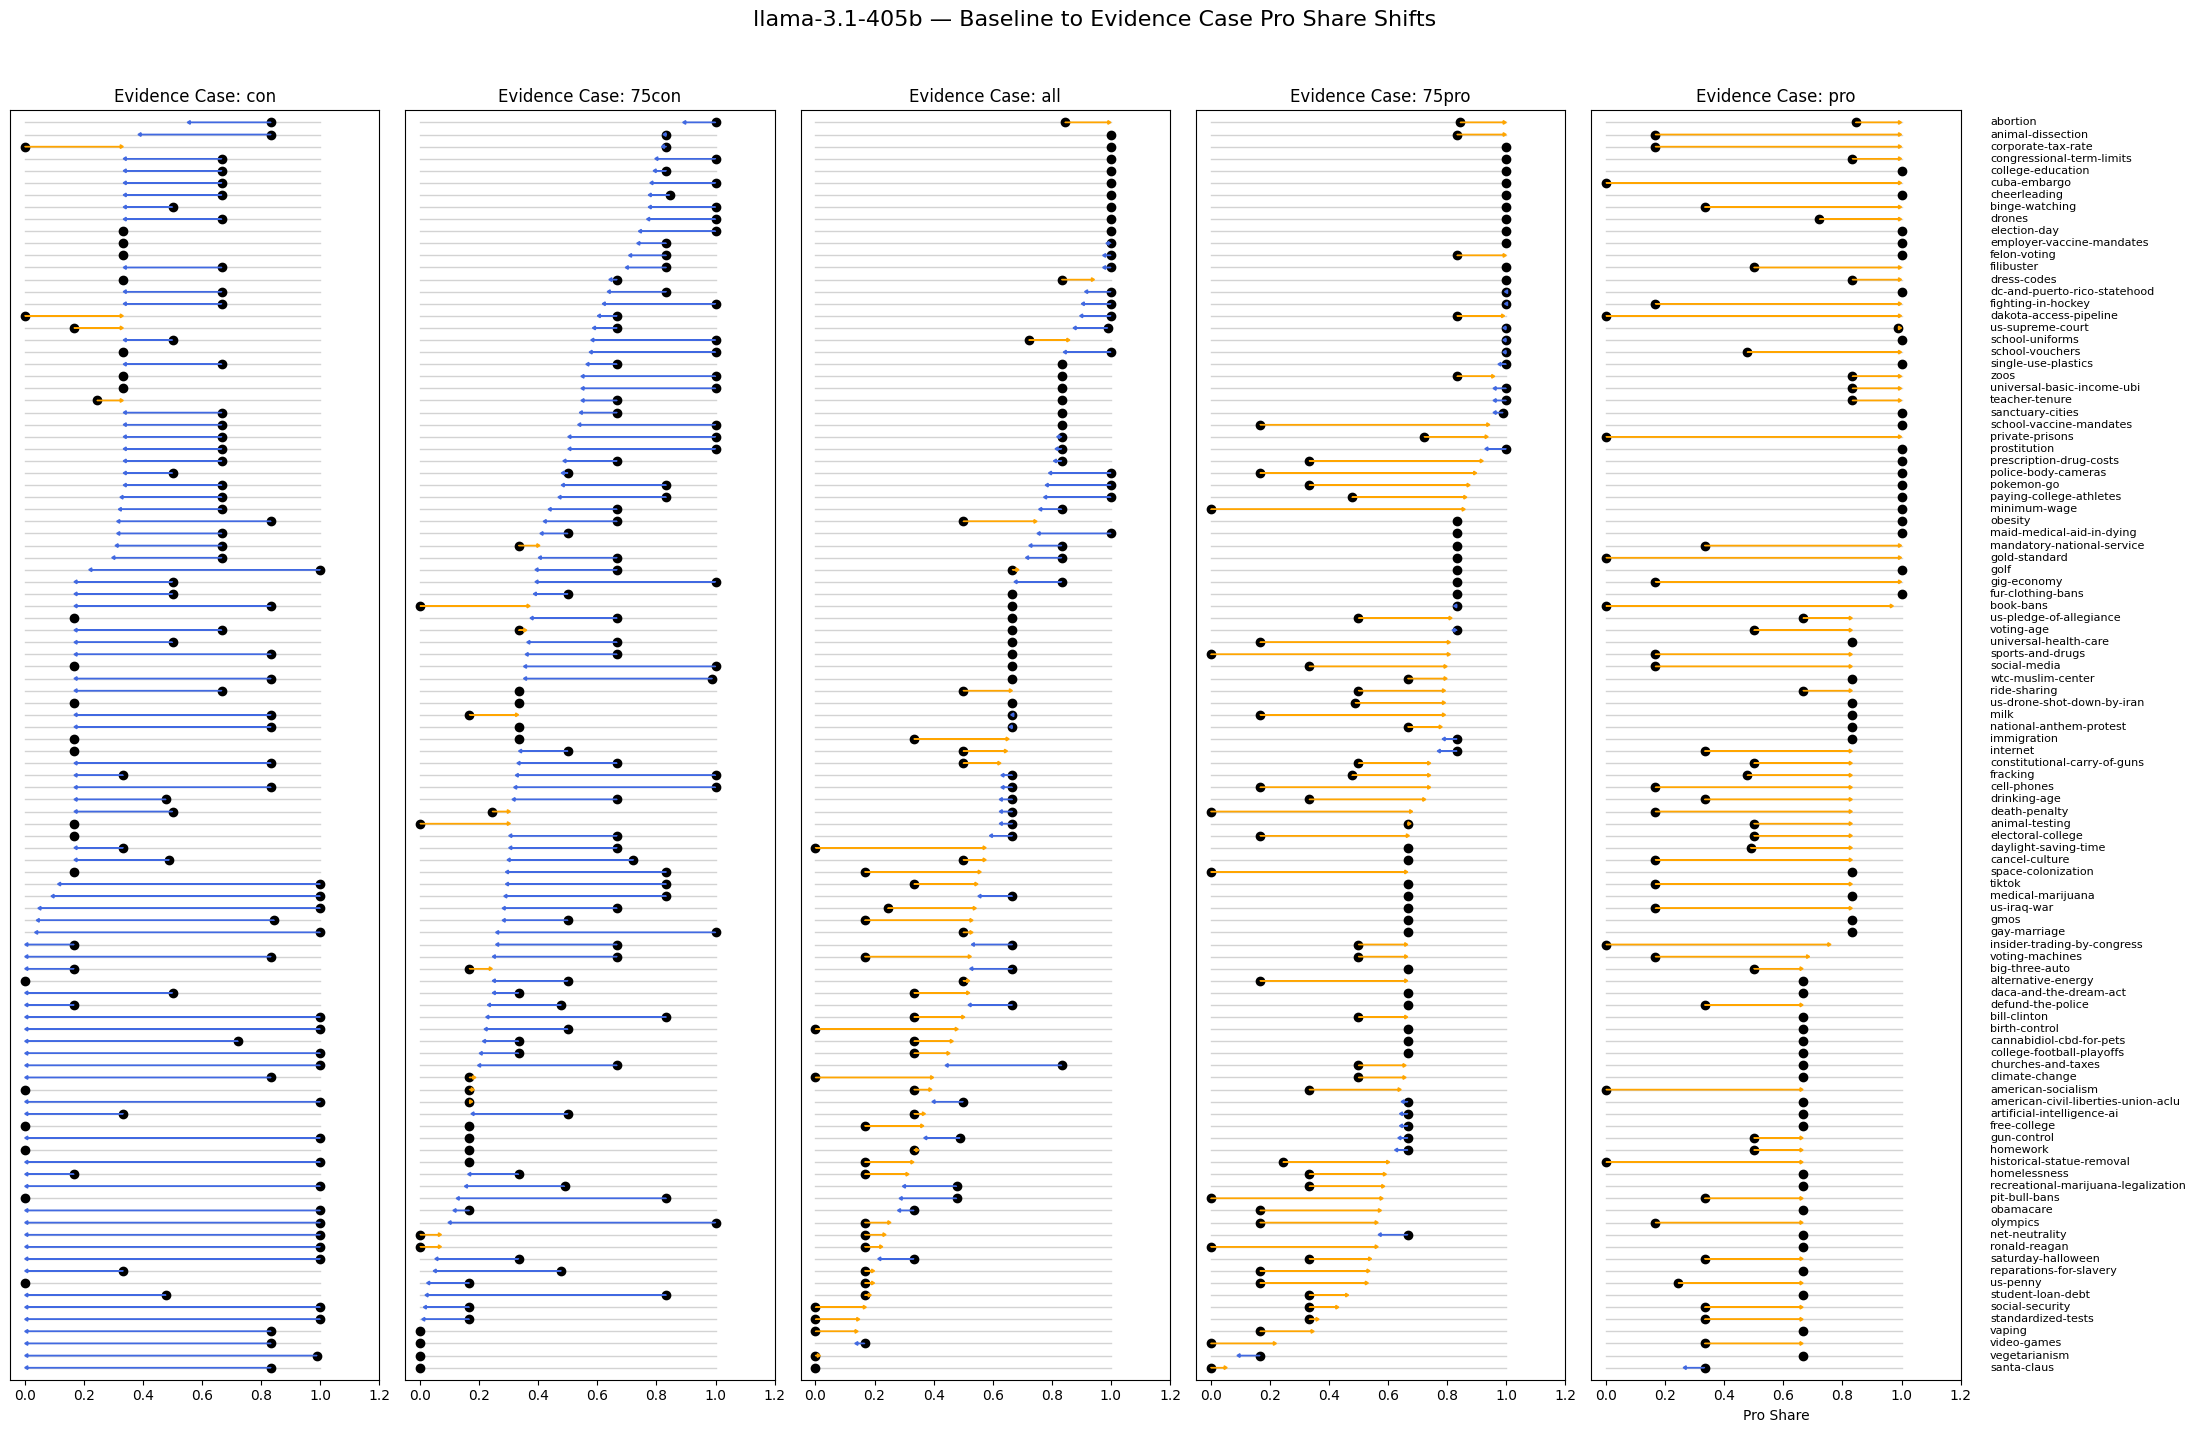

In [114]:
evidence_cases = ['con', '75con', 'all', '75pro', 'pro']
baseline_case = 'neither'
model = 'llama-3.1-405b'  # <-- Replace with your desired model

df = results[model]
# Compute baseline pro share
baseline = df[df['case'] == baseline_case].pivot_table(
    index='issue', columns='issue_stance', values='count', aggfunc='sum', fill_value=0
)
baseline = baseline.div(baseline.sum(axis=1), axis=0).fillna(0)
baseline_pro = baseline.get('pro', pd.Series(0, index=baseline.index))

ncols = 5
nrows = math.ceil(len(evidence_cases) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 14 * nrows), sharex=True)
axes = axes.flatten()

for ax_idx, case in enumerate(evidence_cases):
    case_df = df[df['case'] == case].pivot_table(
        index='issue', columns='issue_stance', values='count', aggfunc='sum', fill_value=0
    )
    case_df = case_df.div(case_df.sum(axis=1), axis=0).fillna(0)
    case_pro = case_df.get('pro', pd.Series(0, index=case_df.index))

    # Only keep issues present in both
    common_issues = baseline_pro.index.intersection(case_pro.index)
    baseline_vals = baseline_pro.loc[common_issues]
    case_vals = case_pro.loc[common_issues]

    # Sort by evidence case outcome value
    sort_idx = case_vals.sort_values(ascending=False).index
    baseline_vals = baseline_vals.loc[sort_idx]
    case_vals = case_vals.loc[sort_idx]

    ax = axes[ax_idx]
    for i, issue in enumerate(sort_idx):
        y = len(sort_idx) - i - 1  # so top is highest value
        # Draw number line
        ax.plot([0, 1], [y, y], color='lightgray', lw=1, zorder=1)
        # Draw baseline dot
        ax.scatter([baseline_vals[issue]], [y], color='black', zorder=2)
        # Draw arrow
        ax.arrow(
            baseline_vals[issue], y,
            case_vals[issue] - baseline_vals[issue], 0,
            head_width=0.3, head_length=0.01, length_includes_head=True,
            color='orange' if case_vals[issue] - baseline_vals[issue] > 0 else 'royalblue',
            zorder=3
        )
        # Only annotate issue name on the far right subplot
        if (ax_idx + 1) % ncols == 0 or ax_idx == len(evidence_cases) - 1:
            ax.text(1.30, y, issue, va='center', ha='left', fontsize=8, clip_on=False)
    ax.set_yticks([])
    ax.set_xlim(-0.05, 1.20)
    ax.set_ylim(-1, len(sort_idx))
    ax.set_title(f"Evidence Case: {case}")

# Hide any unused subplots
for ax in axes[len(evidence_cases):]:
    ax.axis('off')

axes[-1].set_xlabel('Pro Share')
plt.suptitle(f"{model} — Baseline to Evidence Case Pro Share Shifts", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [100]:
baseline_case = 'neither'
evidence_cases = ['pro', 'con']

# Collect all such rows in a list of dicts
unexpected_shifts = []

for model in models:
    df = results[model]
    # Compute baseline pro share
    baseline = df[df['case'] == baseline_case].pivot_table(
        index='issue', columns='issue_stance', values='count', aggfunc='sum', fill_value=0
    )
    baseline = baseline.div(baseline.sum(axis=1), axis=0).fillna(0)
    baseline_pro = baseline.get('pro', pd.Series(0, index=baseline.index))

    for case in evidence_cases:
        case_df = df[df['case'] == case].pivot_table(
            index='issue', columns='issue_stance', values='count', aggfunc='sum', fill_value=0
        )
        case_df = case_df.div(case_df.sum(axis=1), axis=0).fillna(0)
        case_pro = case_df.get('pro', pd.Series(0, index=case_df.index))

        # Only keep issues present in both
        common_issues = baseline_pro.index.intersection(case_pro.index)
        for issue in common_issues:
            shift = case_pro[issue] - baseline_pro[issue]
            if (case == 'pro' and shift < 0) or (case == 'con' and shift > 0):
                unexpected_shifts.append({
                    'model': model,
                    'issue': issue,
                    'evidence_case': case,
                    'baseline_pro': baseline_pro[issue],
                    'evidence_pro': case_pro[issue],
                    'shift': shift
                })

# Convert to DataFrame for easy viewing/sorting
unexpected_df = pd.DataFrame(unexpected_shifts)
print(unexpected_df.sort_values(['model', 'evidence_case', 'shift']).round(3).to_csv(sep='\t', index=False))

model	issue	evidence_case	baseline_pro	evidence_pro	shift
claude-3.5-haiku	olympics	con	0.322	0.328	0.006
claude-3.5-haiku	private-prisons	con	0.0	0.006	0.006
claude-3.5-haiku	defund-the-police	con	0.322	0.333	0.011
claude-3.5-haiku	daylight-saving-time	con	0.156	0.167	0.011
claude-3.5-haiku	us-penny	con	0.267	0.333	0.067
claude-3.5-haiku	historical-statue-removal	con	0.167	0.306	0.139
claude-3.5-haiku	saturday-halloween	pro	0.711	0.667	-0.044
claude-3.5-haiku	college-football-playoffs	pro	0.667	0.644	-0.022
claude-3.5-haiku	election-day	pro	1.0	0.983	-0.017
claude-3.5-haiku	prescription-drug-costs	pro	1.0	0.983	-0.017
claude-3.5-haiku	ride-sharing	pro	0.833	0.817	-0.017
claude-3.5-haiku	american-civil-liberties-union-aclu	pro	0.667	0.661	-0.006
claude-3.5-haiku	free-college	pro	0.667	0.661	-0.006
claude-3.5-haiku	homelessness	pro	0.667	0.661	-0.006
claude-3.5-haiku	minimum-wage	pro	1.0	0.994	-0.006
claude-3.5-haiku	net-neutrality	pro	0.667	0.661	-0.006
claude-3.5-haiku	pokemon-go	pro	

In [113]:
# Get both count and mean for each model
grouped = unexpected_df.groupby(['model'])
count_df = grouped.count().add_suffix('_count')
mean_df = grouped['shift'].apply(lambda x: x.abs().mean()).to_frame().add_suffix('_mean')
result_df = pd.concat([count_df, mean_df], axis=1)
print(result_df[['shift_count', 'shift_mean']].sort_values(by='shift_count', ascending=False))


                  shift_count  shift_mean
model                                    
claude-opus-4              29    0.050192
claude-3.5-haiku           19    0.021053
gemini-2.0-flash           10    0.038228
llama-3.1-8b                9    0.120988
llama-3.1-405b              5    0.198889


In [122]:
top2_abs_shift = unexpected_df.loc[unexpected_df.groupby('model')['shift'].apply(lambda x: x.abs().nlargest(2)).reset_index(level=0, drop=True).index]
print(top2_abs_shift.round(3).to_csv(sep='\t', index=False))

model	issue	evidence_case	baseline_pro	evidence_pro	shift
claude-3.5-haiku	historical-statue-removal	con	0.167	0.306	0.139
claude-3.5-haiku	us-penny	con	0.267	0.333	0.067
claude-opus-4	american-socialism	con	0.133	0.333	0.2
claude-opus-4	gun-control	con	0.167	0.35	0.183
gemini-2.0-flash	ronald-reagan	pro	0.744	0.667	-0.078
gemini-2.0-flash	drinking-age	con	0.089	0.167	0.078
llama-3.1-405b	american-socialism	con	0.0	0.333	0.333
llama-3.1-405b	historical-statue-removal	con	0.0	0.333	0.333
llama-3.1-8b	american-socialism	pro	0.833	0.667	-0.167
llama-3.1-8b	homework	pro	0.833	0.667	-0.167



In [127]:
import os

pros_with_3 = []
cons_with_3 = []
for root, dirs, files in os.walk('../data'):
    if '/pro' in root:
        if len(files) == 3:
            pros_with_3.append(root)
    if '/con' in root:
        if len(files) == 3:
            cons_with_3.append(root)

print(len(pros_with_3))
print(len(cons_with_3))

# print(pros_with_3[0])
# print(cons_with_3[0])


67
65


In [130]:
import pandas as pd
import numpy as np

evidence_cases = ['con', '75con', 'all', '75pro', 'pro']
baseline_case = 'neither'

top_openminded = {}

for model in models:
    df = results[model]
    # Compute baseline pro share
    baseline = df[df['case'] == baseline_case].pivot_table(
        index='issue', columns='issue_stance', values='count', aggfunc='sum', fill_value=0
    )
    baseline = baseline.div(baseline.sum(axis=1), axis=0).fillna(0)
    baseline_pro = baseline.get('pro', pd.Series(0, index=baseline.index))
    # Compute mean absolute shift for each issue
    abs_shifts = []
    for case in evidence_cases:
        case_df = df[df['case'] == case].pivot_table(
            index='issue', columns='issue_stance', values='count', aggfunc='sum', fill_value=0
        )
        case_df = case_df.div(case_df.sum(axis=1), axis=0).fillna(0)
        case_pro = case_df.get('pro', pd.Series(0, index=case_df.index))
        for issue in baseline_pro.index.intersection(case_pro.index):
            shift = abs(case_pro[issue] - baseline_pro[issue])
            abs_shifts.append({'issue': issue, 'case': case, 'shift': shift})
    # Aggregate by issue
    abs_shifts_df = pd.DataFrame(abs_shifts)
    mean_shift = abs_shifts_df.groupby('issue')['shift'].mean()
    top5 = mean_shift.sort_values(ascending=False).head(5)
    top_openminded[model] = top5
    print(f"\nTop 5 most open-minded issues for {model}:")
    print(top5)

# Optionally, visualize as a heatmap or bar plot


Top 5 most open-minded issues for claude-3.5-haiku:
issue
dress-codes                   0.513333
corporate-tax-rate            0.472222
gig-economy                   0.457778
mandatory-national-service    0.457778
pokemon-go                    0.441111
Name: shift, dtype: float64

Top 5 most open-minded issues for claude-opus-4:
issue
zoos              0.526667
election-day      0.500000
cheerleading      0.498889
pokemon-go        0.456667
teacher-tenure    0.455556
Name: shift, dtype: float64

Top 5 most open-minded issues for gemini-2.0-flash:
issue
pokemon-go      0.678889
cheerleading    0.573333
felon-voting    0.532222
election-day    0.520000
dress-codes     0.516667
Name: shift, dtype: float64

Top 5 most open-minded issues for llama-3.1-405b:
issue
american-socialism           0.523333
historical-statue-removal    0.471111
dress-codes                  0.452222
binge-watching               0.438889
pokemon-go                   0.433333
Name: shift, dtype: float64

Top 5 most 

In [ ]:
baseline_hi_average_diff_issues = ['school-uniforms', 'binge-watching', 'gig-economy']

In [ ]:
baseline_hi_average_diff_issues = ['school-uniforms', 'binge-watching', 'gig-economy']

In [ ]:
models = list(results.keys())
model_pairs = list(combinations(models, 2))

for (model1, model2) in model_pairs:
    # Get pro_share for all (case, issue) tuples for each model
    def get_pro_share_vector(model, cases):
        df = results[model]
        df_filtered = df[
            (df['issue_stance'].isin(['pro', 'con', 'other']))
            & (df['case'].isin(cases))
        ]
        stance_counts = df_filtered.pivot_table(
            index=['case', 'issue'],
            columns='issue_stance',
            values='count',
            fill_value=0
        )
        stance_counts['total'] = stance_counts.sum(axis=1)
        stance_counts['pro_share'] = stance_counts['pro'] / stance_counts['total']
        return stance_counts['pro_share']

    # For each model pair, plot a single figure with a subfigure (subplot) for each case set
    fig, axes = plt.subplots(1, 3, figsize=(24, 8), sharex=True, sharey=True)
    case_sets = [['neither', 'all'], ['75pro', '75con'], ['pro', 'con']]
    for i, cases in enumerate(case_sets):
        pro_share1 = get_pro_share_vector(model1, cases)
        pro_share2 = get_pro_share_vector(model2, cases)

        # Find common (case, issue) tuples
        common_tuples = pro_share1.index.intersection(pro_share2.index)
        pro_share1 = pro_share1.loc[common_tuples]
        pro_share2 = pro_share2.loc[common_tuples]

        # Compute outliers
        diff = (pro_share1 - pro_share2).abs()
        outliers = diff.sort_values(ascending=False)
        top_outlier_indices = outliers.head(10).index

        # Print the top 10 outliers
        print(f"Top 10 outliers for {model1} vs {model2} (most disagreement) for cases {cases}:")
        for idx in top_outlier_indices:
            print(f"{idx}: {model1}={pro_share1[idx]:.2f}, {model2}={pro_share2[idx]:.2f}, diff={diff[idx]:.2f}")

        # Scatterplot in subfigure
        ax = axes[i]
        ax.scatter(pro_share1, pro_share2, alpha=0.5, label='All points')
        # Highlight top 10 outliers in red
        ax.scatter(pro_share1.loc[top_outlier_indices], pro_share2.loc[top_outlier_indices], color='red', label='Top 10 outliers')
        ax.set_xlabel(f"Pro Share ({model1})")
        if i == 0:
            ax.set_ylabel(f"Pro Share ({model2})")
        ax.set_title(f"Cases: {', '.join(cases)}")
        # Annotate with Pearson correlation
        corr = np.corrcoef(pro_share1, pro_share2)[0, 1]
        ax.text(0.05, 0.95, f"Pearson r = {corr:.2f}", transform=ax.transAxes, fontsize=12, va='top')
        ax.legend()
        ax.grid(True)

    plt.suptitle(f"Pro Share Agreement: {model1} vs {model2} (by case set)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    os.makedirs('../figures', exist_ok=True)
    plt.savefig(f'../figures/pro_share_scatter_{model1}_vs_{model2}_subfigs.png', dpi=300)
    plt.show()

In [ ]:
models = list(results.keys())
issues = sorted(results[models[0]]['issue'].unique())
n_models = len(models)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig_width = max(16, n_cols * 16)
fig_height = max(10, n_rows * 15)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height), squeeze=False)

for idx, model in enumerate(models):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row, col]
    df = results[model]
    df_filtered = df[df['issue_stance'].isin(['pro', 'con', 'neither', 'other'])]  # adjust as needed
    stance_counts = df_filtered.pivot_table(
        index=['case', 'issue'],
        columns='issue_stance',
        values='count',
        fill_value=0
    )
    stance_counts['total'] = stance_counts.sum(axis=1)
    stance_counts['pro_share'] = stance_counts['pro'] / stance_counts['total']
    pro_share_matrix = stance_counts['pro_share'].unstack('issue')
    corr = pro_share_matrix.corr()

    sns.heatmap(
        corr,
        xticklabels=pro_share_matrix.columns,
        yticklabels=pro_share_matrix.columns,
        annot=False,
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        ax=ax
    )
    ax.set_xlabel("Issues")
    ax.set_ylabel("Issues")
    ax.set_title(f"Topic Correlation: {model}")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# Hide any unused subplots
for idx in range(n_models, n_rows * n_cols):
    row = idx // n_cols
    col = idx % n_cols
    fig.delaxes(axes[row, col])

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/per_model_topic_correlation_heatmaps.png', dpi=300)
plt.show()

In [ ]:
df = pd.concat(results.values())
cases_of_interest = ['neither']
# cases = df['case'].unique()
df = df[df['case'].isin(cases_of_interest)]
issues = df['issue'].unique()
issues = issues[~np.isin(issues, remove_issues)]
n_issues = len(issues)

ncols = 4  # Adjust as needed for readability
nrows = math.ceil(n_issues / ncols)

# Define the desired model order for the plots
ordered_models = ['llama-3.1-8b', 'llama-3.1-405b', 'claude-3.5-haiku', 'claude-opus-4', 'gemini-2.0-flash']

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*2.5), squeeze=False)

for idx, issue in enumerate(issues):
    row, col = divmod(idx, ncols)
    ax = axes[row, col]
    filtered = df[df['issue'] == issue]
    data = []
    for model in ordered_models:
        sub = filtered[filtered['model'] == model]
        counts = sub.groupby('issue_stance')['count'].sum().reindex(stances, fill_value=0)
        shares = counts / counts.sum() if counts.sum() > 0 else counts
        data.append(shares.values)
    if len(data) == 0:
        continue
    data_df = pd.DataFrame(data, columns=stances, index=ordered_models)
    left = pd.Series([0]*len(data_df), index=data_df.index)
    for stance in stances:
        ax.barh(data_df.index, data_df[stance], left=left, color=colors[stance], label=stance)
        left += data_df[stance]
    ax.set_title(issue)
    ax.set_xlabel('Share')
    ax.set_xlim(0, 1)
    if col == 0:
        ax.set_ylabel('Model')
    else:
        ax.set_yticklabels([])
    
    ax.legend().set_visible(False)

# Hide any unused subplots
for idx in range(n_issues, nrows * ncols):
    row, col = divmod(idx, ncols)
    axes[row, col].axis('off')

handles = [plt.Rectangle((0,0),1,1, color=colors[stance]) for stance in stances]
labels = [stance.capitalize() for stance in stances]
fig.legend(handles, labels, title='Stance', loc='upper center', bbox_to_anchor=(0.5, 0.97), ncol=3, fontsize=20, title_fontsize=24)

fig.suptitle(f"Baseline stances with no evidence for all models", fontsize=32)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space at the top for the suptitle
plt.savefig(f"../figures/neither_all_models.png", dpi=300)